In [16]:
import pickle
import numpy as np
from matplotlib import pyplot as plt

In [17]:
train_data = pickle.load(open("../yoochoose_original_sessions/train.txt", 'rb'))
test_data = pickle.load(open("../yoochoose_original_sessions/test.txt", 'rb'))

In [18]:
import copy
def calculate_global_mean_dwell_time(sessions_times):
    max_du = 0
    total_duration_sum = 0.0
    total_transitions = 0
    
    sessions = copy.deepcopy(sessions_times)
    for session in sessions:
        if len(session) > 1:
            for idx in range(1, len(session)):
                # Dwell Time bruto
                delta_t = session[idx] - session[idx-1]
                max_du = max(max_du, delta_t)
                if delta_t < 0:
                    print("ERROR", delta_t)
                total_duration_sum += delta_t
                total_transitions += 1
    print(max_du)
                
    if total_transitions > 0:
        mu_g = total_duration_sum / total_transitions
    else:
        mu_g = 1.0 
        
    return mu_g

In [19]:
import math
def process_times(sessions_times:list[int], operation="trunc"):
    g_mean = math.log(calculate_global_mean_dwell_time(sessions_times) + 1)
    output_cont = []
    output_bins = []
    
    min_diff = float("inf")
    max_diff = float("-inf")
  
    for session in sessions_times:
        dwell = []
        bins = []
        [4,6]
        []
        if len(session) > 1:
            for idx in range(1, len(session)):
                d_time = math.log(session[idx] - session[idx-1] + 1)
                min_diff = min(min_diff, d_time)
                max_diff = max(max_diff, d_time)
                dwell.append(d_time)
                bins.append(int(d_time) if operation == "trunc" else round(d_time))
        
        dwell.append(g_mean) # last time
        bins.append(int(g_mean) if operation == "trunc" else round(g_mean))
        # else:
        #     dwell.append(g_mean)
        #     bins.append(int(g_mean) if operation == "trunc" else round(g_mean))
                        
        # if len(dwell) > 1:
        #     dwell.append(g_mean) # last time
        #     bins.append(int(g_mean) if operation == "trunc" else round(g_mean))
        
        output_cont.append(dwell)
        output_bins.append(bins)
        
    return output_cont, output_bins, int(math.floor(min_diff)), int(math.ceil(max_diff))

In [20]:
def plot_dwell_sessions(d_sessions):
    max_sess_len = max([len(s) for s in d_sessions])
    for i in range(len(d_sessions)):
        d_sessions[i] = d_sessions[i] + [0] * (max_sess_len - len(d_sessions[i]))
    for s in d_sessions:
        plt.plot(np.arange(1, max_sess_len + 1), np.log1p(s))
    plt.show()

In [21]:
def get_bins_freq(session_data, min_bin, max_bin):
    bins_freq = np.arange(min_bin, max_bin + 1)
    for session in session_data:
        for bin_ in session:  
            bins_freq[bin_-1] += 1
    return bins_freq

In [22]:
times_train = train_data[2]
output_cont, output_bins_train, min_bin, max_bin = process_times(times_train, operation="round")
bins_freq = get_bins_freq(output_bins_train, min_bin, max_bin)

3622


In [23]:
max_bin

9

In [14]:
times_test = test_data[2]
output_cont, output_bins_test, min_bin, max_bin = process_times(times_test, operation="round")
bins_freq = get_bins_freq(output_bins_train, min_bin, max_bin)

3599


In [15]:
len(train_data[0])

124472

In [11]:
print(type(train_data[0][:5]))

<class 'list'>


In [12]:
print(train_data[0][:10])

[[2667, 34425], [37094], [36479, 36479, 34182, 34182, 36479, 36479, 12899], [33901, 30894], [36972], [37014], [36951, 36967, 36967], [16444, 36479], [36918, 37215, 1355, 32100], [37111]]


In [13]:
print(type(output_bins_train[0][:5]))

<class 'list'>


In [14]:
print(output_bins_train[:10])

[[4, 5], [5], [2, 5, 2, 7, 2, 7, 5], [5, 5], [5], [5], [2, 6, 5], [4, 5], [5, 3, 4, 5], [5]]


In [15]:
len(output_bins_train)

124472

In [16]:
tra = (train_data[0], train_data[1], train_data[2], output_bins_train)
tes = (test_data[0], test_data[1], test_data[2], output_bins_test)

In [17]:
NEW_DATASET_FOLDER = "../yoochoose_1_64_bins"

In [18]:
pickle.dump(tra, open(f'{NEW_DATASET_FOLDER}/train.txt', 'wb'))
pickle.dump(tes, open(f'{NEW_DATASET_FOLDER}/test.txt', 'wb'))
# pickle.dump(seq64, open(f'{NEW_DATASET_FOLDER}/all_train_seq.txt', 'wb'))

In [19]:
def save_as_txt(data_list, filename):
    """
    Guarda una lista de secuencias (o listas) en un archivo de texto, 
    donde cada secuencia se convierte en una línea separada y los elementos 
    dentro de la secuencia se unen por un espacio.
    """
    with open(filename, 'w') as f:
        for sequence in data_list:
            # Asegura que todos los elementos sean strings antes de unirlos
            line = ' '.join(map(str, sequence))
            f.write(line + '\n')
    print(f"Guardado exitosamente como texto legible en: {filename}")


save_as_txt(tra, f'{NEW_DATASET_FOLDER}/train_txt.txt')
save_as_txt(tes, f'{NEW_DATASET_FOLDER}/test_txt.txt')
# save_as_txt(seq64, f'{NEW_DATASET_FOLDER}/all_train_seq_txt.txt')

Guardado exitosamente como texto legible en: ../yoochoose_1_64_bins/train_txt.txt
Guardado exitosamente como texto legible en: ../yoochoose_1_64_bins/test_txt.txt


<BarContainer object of 10 artists>

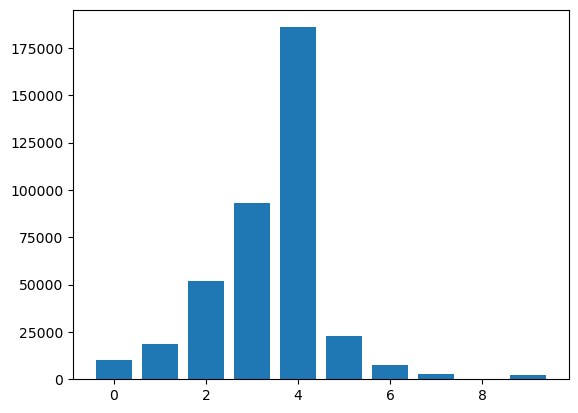

In [20]:
plt.bar(np.arange(max_bin + 1), bins_freq)

In [21]:
bins_freq

array([ 10254,  18499,  51644,  93354, 185909,  22818,   7403,   2589,
            8,   2370])

In [23]:
sum(bins_freq)

394848

In [24]:
sum([len(x) for x in train_data])

373416

<BarContainer object of 10 artists>

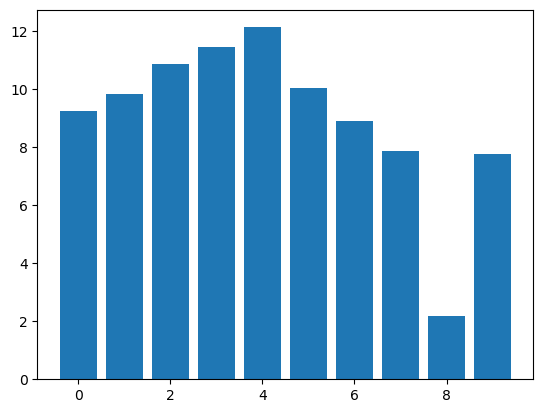

In [22]:
plt.bar(np.arange(max_bin + 1), np.log1p(bins_freq))

In [12]:
plt.bar(np.arange(max_bin + 1), bins_freq)

NameError: name 'bins_freq' is not defined

In [13]:
plt.bar(np.arange(max_bin + 1), bins_freq)

NameError: name 'bins_freq' is not defined

In [14]:
plt.bar(np.arange(max_bin + 1), np.log1p(bins_freq))

NameError: name 'bins_freq' is not defined